# Full-Stack Profiling and Results

Runs the complete analytics pipeline (RQ1–RQ3) in both **naive** and **optimized** forms,
times each stage, and surfaces the final research findings.
A's preprocessing backbone is pre-built; this notebook benchmarks everything downstream.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_candidates = [
    Path('/Users/fqxin/Desktop/1019_Py/football_lifecycle'),
    Path('/content/drive/MyDrive/football_lifecycle'),
    Path('../'),
]
PROJECT_ROOT = next(
    (p.resolve() for p in _candidates if (p / 'data' / 'processed').exists()), None
)
if PROJECT_ROOT is None:
    raise RuntimeError('Cannot find project root. Add your path to _candidates above.')
sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)

PROCESSED     = PROJECT_ROOT / 'data' / 'processed'
INTERIM       = PROJECT_ROOT / 'data' / 'interim'
OUT_TABLES    = PROJECT_ROOT / 'outputs' / 'tables'
OUT_FIGURES   = PROJECT_ROOT / 'outputs' / 'figures'
OUT_PROFILING = PROJECT_ROOT / 'outputs' / 'profiling'

for d in [OUT_TABLES, OUT_FIGURES, OUT_PROFILING]:
    d.mkdir(parents=True, exist_ok=True)

POSITION_ORDER = ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']
POSITION_PALETTE = {
    'Goalkeeper': '#1976D2',
    'Defender':   '#388E3C',
    'Midfielder': '#F57C00',
    'Forward':    '#D32F2F',
}
plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 150, 'font.size': 11})

Project root: /Users/fqxin/Desktop/1019_Py/football_lifecycle


In [2]:
from src.d_rq3_decline_utils import (
    d_pipeline_naive,
    d_pipeline_optimized,
)

In [3]:
import cProfile
%load_ext line_profiler

## 1) Load shared data

In [4]:
t0 = time.perf_counter()
backbone = pd.read_parquet(PROCESSED / 'player_lifecycle_backbone.parquet')
perf     = pd.read_parquet(INTERIM  / 'player_performances_clean.parquet')
t_load   = time.perf_counter() - t0

n_players = backbone['player_id'].nunique()
print(f'Backbone:    {backbone.shape}   loaded in {t_load:.2f}s')
print(f'Performance: {perf.shape}')
print(f'Players:     {n_players:,}')

Backbone:    (836635, 13)   loaded in 0.45s
Performance: (1878719, 21)
Players:     58,944


## 2) RQ1: Peak Age by Position

**Naive — `groupby.apply` with per-group lambda** <br>
For each of the 58,944 player groups, a Python lambda filters rows to those matching
the player's max market value, then picks `iloc[0]`. This invokes the Python interpreter
58,944 times inside the apply loop.

**Bottleneck (`%lprun`- line-profiler)** <br>
`.apply(lambda …)` accounts for **99.5% of total runtime** (≈25s out of 25.1s).
The sort beforehand is negligible (0.5%). The entire cost is Python-level iteration.

**Optimization — boolean filter + `groupby.first()`** <br>
The backbone pre-computes `is_peak_value_obs` (True when `market_value_eur` equals the
player's maximum). A single vectorized boolean mask extracts peak rows; `sort_values`
then `groupby.first()` resolves ties by earliest date. All operations stay in C — zero
Python-level group iteration.

In [5]:
def b_naive(data): # same as compute_peak_age_naive in part B
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', FutureWarning)
        out = (
            data.sort_values(["player_id", "market_value_date"])
                .groupby("player_id", observed=True)
                .apply(lambda x: x.loc[x["market_value_eur"].eq(x["market_value_eur"].max())].iloc[0])
                .reset_index(drop=True)
        )
    return out

cProfile.run('b_naive(backbone)')

         110824226 function calls (108702004 primitive calls) in 22.770 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.007    0.007   22.770   22.770 2140182522.py:1(b_naive)
    58944    0.187    0.000   20.791    0.000 2140182522.py:7(<lambda>)
        8    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:1053(_handle_fromlist)
        1    0.001    0.001   22.770   22.770 <string>:1(<module>)
   412619    0.044    0.000    0.044    0.000 __init__.py:34(using_copy_on_write)
   117891    0.013    0.000    0.013    0.000 __init__.py:42(warn_copy_on_write)
        9    0.000    0.000    0.000    0.000 __init__.py:55(using_string_dtype)
        9    0.000    0.000    0.000    0.000 _asarray.py:109(<setcomp>)
        9    0.000    0.000    0.000    0.000 _asarray.py:27(require)
        1    0.000    0.000    0.000    0.000 _collections_abc.py:262(__subclasshook__)
        5    0.000    0.000    0.

In [6]:
%lprun -f b_naive b_naive(backbone)

Timer unit: 1e-09 s

Total time: 24.6865 s
File: /var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2140182522.py
Function: b_naive at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def b_naive(data): # same as compute_peak_age_naive in part B
     2         2       8000.0   4000.0      0.0      with warnings.catch_warnings():
     3         1       5000.0   5000.0      0.0          warnings.simplefilter('ignore', FutureWarning)
     4         1          0.0      0.0      0.0          out = (
     5         3   95072000.0 3.17e+07      0.4              data.sort_values(["player_id", "market_value_date"])
     6         1          0.0      0.0      0.0                  .groupby("player_id", observed=True)
     7         1     2.46e+10 2.46e+10     99.6                  .apply(lambda x: x.loc[x["market_value_eur"].eq(x["market_value_eur"].max())].iloc[0])
     8         1       2000.0   2000.0      0.0

In [7]:
def b_optimized(data): # same as compute_peak_age_optimized in part B
    peak = (
        data.loc[data["is_peak_value_obs"].fillna(False)]
            .sort_values(["player_id", "market_value_date"])
    )
    out = peak.groupby("player_id", observed=True).first().reset_index()
    return out

t0 = time.perf_counter()
b_out_naive = b_naive(backbone)
t_b_naive   = time.perf_counter() - t0

t0 = time.perf_counter()
b_out_opt   = b_optimized(backbone)
t_b_opt     = time.perf_counter() - t0

print(f'B naive:     {t_b_naive:.3f}s   ({len(b_out_naive):,} players)')
print(f'B optimized: {t_b_opt:.3f}s   ({len(b_out_opt):,} players)')
print(f'Speedup: {t_b_naive / t_b_opt:.1f}x')

B naive:     12.304s   (58,944 players)
B optimized: 0.072s   (58,944 players)
Speedup: 171.2x


## 3) RQ2: Peak Performance by Position

**Naive — full join → sort → `groupby.first()`** <br>
The full backbone (836K rows) is merged with the full performance table (1.88M rows),
producing a ~2.2M-row intermediate. The merged table is then sorted by
`['player_id', 'performance']` to bring each player's best season to the top, before
`groupby.first()` extracts it.


**Bottleneck (`%lprun` - line-profiler)** <br>
| Step | % time | Why it's expensive |
|---|---|---|
| `groupby.first()` | 41.5% | Scans and extracts the first row of every group after sorting |
| `b.merge(p, …)` | 33.0% | Hash-join on 836K × 1.88M rows; large intermediate |
| `sort_values(…)` | 18.6% | O(n log n) sort on 2.2M rows |

The root cause is carrying all 21 columns through the merge, then sorting the full
2.2M-row result just to find one row per player.



**Optimization — column projection + `idxmax()`** <br>
Two changes eliminate the dominant costs:
1. **Project to needed columns before merging** — backbone down to 4 columns, performance
   table down to 3. The join result is narrower, so the merge is cheaper and less memory
   is moved.
2. **Replace sort + `groupby.first()` with `groupby.idxmax()`** — a single O(n) scan
   returns the index of each player's highest-performance row directly. No sort needed.

In [8]:
def c_naive(bb, pf):
    p = pf.assign(performance=pf['goals'].fillna(0) + pf['assists'].fillna(0))
    b = bb.copy()
    b['market_value_year'] = pd.to_datetime(b['market_value_date']).dt.year
    merged = b.merge(
        p,
        left_on=['player_id', 'market_value_year'],
        right_on=['player_id', 'season_start_year'],
        how='inner',
    )
    peak = merged.sort_values(['player_id', 'performance'], ascending=[True, False]) \
              .groupby('player_id', as_index=False) \
              .first()
    return (peak.groupby('broad_position')
            .agg(
                n_players=('player_id', 'nunique'),
                mean_perf=('performance', 'mean'),
                median_perf=('performance', 'median'),
                mean_age=('age_years', 'mean'),
                median_age=('age_years', 'median')
            )
            .reset_index()
    )

cProfile.run('c_naive(backbone, perf)')

         26664 function calls (26003 primitive calls) in 1.647 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.031    0.031    1.579    1.579 2863803126.py:1(c_naive)
       37    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:1053(_handle_fromlist)
        1    0.068    0.068    1.647    1.647 <string>:1(<module>)
        5    0.000    0.000    0.000    0.000 <string>:2(__hash__)
        5    0.000    0.000    0.000    0.000 <string>:2(__init__)
       78    0.000    0.000    0.000    0.000 __init__.py:34(using_copy_on_write)
       17    0.000    0.000    0.000    0.000 __init__.py:42(warn_copy_on_write)
       34    0.000    0.000    0.000    0.000 __init__.py:55(using_string_dtype)
        2    0.000    0.000    0.000    0.000 _asarray.py:109(<setcomp>)
        2    0.000    0.000    0.000    0.000 _asarray.py:27(require)
        2    0.000    0.000    0.000    0.000 _collections_abc.py:26

/var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2863803126.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (peak.groupby('broad_position')


In [9]:
%lprun -f c_naive c_naive(backbone, perf)

/var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2863803126.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (peak.groupby('broad_position')


Timer unit: 1e-09 s

Total time: 1.53258 s
File: /var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2863803126.py
Function: c_naive at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def c_naive(bb, pf):
     2         1   55404000.0 5.54e+07      3.6      p = pf.assign(performance=pf['goals'].fillna(0) + pf['assists'].fillna(0))
     3         1   12991000.0  1.3e+07      0.8      b = bb.copy()
     4         1   17043000.0  1.7e+07      1.1      b['market_value_year'] = pd.to_datetime(b['market_value_date']).dt.year
     5         2  485544000.0 2.43e+08     31.7      merged = b.merge(
     6         1          0.0      0.0      0.0          p,
     7         1          0.0      0.0      0.0          left_on=['player_id', 'market_value_year'],
     8         1          0.0      0.0      0.0          right_on=['player_id', 'season_start_year'],
     9         1          0.0      0.0      0.0         

In [10]:
def c_optimized(bb, pf):
    p = pf.assign(performance=pf['goals'].fillna(0) + pf['assists'].fillna(0))
    b = bb.copy()
    b['market_value_year'] = pd.to_datetime(b['market_value_date']).dt.year
    
    # Only keep columns needed for merge
    b = b[['player_id', 'market_value_year', 'broad_position', 'age_years']]
    p = p[['player_id', 'season_start_year', 'performance']]

    merged = b.merge(
        p,
        left_on=['player_id', 'market_value_year'],
        right_on=['player_id', 'season_start_year'],
        how='inner',
    )
    # O(n) single scan to locate the peak-performance row per player — no sort needed
    idx = merged.groupby('player_id')['performance'].idxmax()
    peak = merged.loc[idx].reset_index(drop=True)
    return (peak.groupby('broad_position')
            .agg(
                n_players=('player_id', 'nunique'),
                mean_perf=('performance', 'mean'),
                median_perf=('performance', 'median'),
                mean_age=('age_years', 'mean'),
                median_age=('age_years', 'median')
            )
            .reset_index()
    )

%lprun -f c_optimized c_optimized(backbone, perf)

/var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2348729075.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (peak.groupby('broad_position')


Timer unit: 1e-09 s

Total time: 0.486703 s
File: /var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2348729075.py
Function: c_optimized at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def c_optimized(bb, pf):
     2         1   56013000.0  5.6e+07     11.5      p = pf.assign(performance=pf['goals'].fillna(0) + pf['assists'].fillna(0))
     3         1   15987000.0  1.6e+07      3.3      b = bb.copy()
     4         1   19709000.0 1.97e+07      4.0      b['market_value_year'] = pd.to_datetime(b['market_value_date']).dt.year
     5                                               
     6                                               # Only keep columns needed for merge
     7         1   12989000.0  1.3e+07      2.7      b = b[['player_id', 'market_value_year', 'broad_position', 'age_years']]
     8         1   32094000.0 3.21e+07      6.6      p = p[['player_id', 'season_start_year', 'performance']]
 

In [11]:
t0 = time.perf_counter()
c_out_naive = c_naive(backbone, perf)
t_c_naive   = time.perf_counter() - t0

t0 = time.perf_counter()
c_out_opt = c_optimized(backbone, perf)
t_c_opt   = time.perf_counter() - t0

print(f'C naive:     {t_c_naive:.3f}s   ({len(c_out_naive):,} players)')
print(f'C optimized: {t_c_opt:.3f}s   ({len(c_out_opt):,} players)')
print(f'Speedup: {t_c_naive / t_c_opt:.1f}x')

/var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2863803126.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (peak.groupby('broad_position')


C naive:     1.617s   (5 players)
C optimized: 0.430s   (5 players)
Speedup: 3.8x


/var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2348729075.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (peak.groupby('broad_position')


## 4) RQ3: Post-Peak Decline Rates

**Naive — `groupby.apply` + `scipy.linregress` per player** <br>
After filtering to post-peak rows, `compute_decline_slopes_base` runs
`groupby.apply(_slope)` where `_slope` calls `scipy.linregress` on each player's group.
With ~39K eligible players this is 39K sequential Python function calls — the GIL is
held for every group, and `linregress` carries full import-and-dispatch overhead on
groups that are typically only 4–6 rows.

**Bottleneck** <br>
The entire cost is the per-player Python loop in `groupby.apply`. `scipy.linregress`
itself solves a 2-parameter OLS via SVD, which is heavy machinery for groups this small.

**Optimization — vectorized closed-form OLS** <br>
`compute_decline_slopes_vectorized` computes the same OLS slope using the closed-form:
$$\hat{\beta} = \frac{n\sum xy - \sum x \sum y}{n\sum x^2 - (\sum x)^2}$$

A single `groupby.agg` accumulates `Σx, Σy, Σx², Σxy, n` across all players in one
C-backed pass. The slope is then evaluated element-wise with NumPy — no Python loop,
no per-player function call, no SVD overhead.

In [12]:
t0 = time.perf_counter()
d_peak_naive, d_post_naive, d_slopes_naive = d_pipeline_naive(backbone)
t_d_naive = time.perf_counter() - t0

t0 = time.perf_counter()
d_peak_opt, d_post_opt, d_decline_opt = d_pipeline_optimized(backbone)
t_d_opt = time.perf_counter() - t0

print(f'D naive:     {t_d_naive:.3f}s   ({len(d_peak_naive):,} players)')
print(f'D optimized: {t_d_opt:.3f}s   ({len(d_peak_opt):,} players)')
print(f'Speedup: {t_d_naive / t_d_opt:.1f}x')

D naive:     2.702s   (58,944 players)
D optimized: 0.473s   (58,944 players)
Speedup: 5.7x


## 5) Full-Stack Timing Summary

,Naive (s),Optimized (s),Speedup
Stage,,,
peak age,12.304,0.072,171.2
peak performance,1.617,0.430,3.8
decline rate,2.702,0.473,5.7
Total,16.623,0.975,17.0


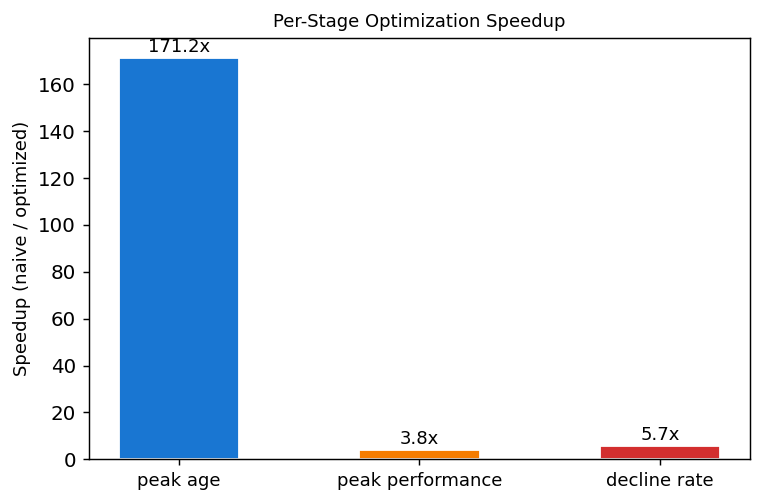

In [13]:
timing = pd.DataFrame({
    'Stage': [
        'peak age',
        'peak performance',
        'decline rate',
        'Total',
    ],
    'Naive (s)': [
        t_b_naive, t_c_naive, t_d_naive,
        t_b_naive + t_c_naive + t_d_naive,
    ],
    'Optimized (s)': [
        t_b_opt, t_c_opt, t_d_opt,
        t_b_opt + t_c_opt + t_d_opt,
    ],
})
timing['Speedup'] = (timing['Naive (s)'] / timing['Optimized (s)']).round(1)
timing[['Naive (s)', 'Optimized (s)']] = timing[['Naive (s)', 'Optimized (s)']].round(3)

display(timing.set_index('Stage'))

# Bar chart of per-stage speedups
fig, ax = plt.subplots(figsize=(6, 4))
stages   = timing['Stage'].iloc[:3]
speedups = timing['Speedup'].iloc[:3]
colors   = [POSITION_PALETTE['Goalkeeper'], POSITION_PALETTE['Midfielder'], POSITION_PALETTE['Forward']]
bars = ax.bar(stages, speedups, color=colors, width=0.5, edgecolor='white', linewidth=1)
for bar, val in zip(bars, speedups):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.0,
        f'{val:.1f}x',
        ha='center', va='bottom', fontsize=10, 
    )
ax.set_ylabel('Speedup (naive / optimized)', fontsize=10)
ax.set_title('Per-Stage Optimization Speedup', fontsize=10)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig(OUT_FIGURES / 'E_speedup_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 6) Numba JIT Acceleration 

**Idea**
Even the vectorized pandas OLS still dispatches through Pandas groupby machinery.
`@njit` compiles a Python function to native machine code via LLVM:
integer-encode `player_id` → sort once → single compiled pass accumulating
`Σx, Σy, Σx², Σxy, n` per group → compute slope with register-level arithmetic.
No Python interpreter in the inner loop.

**Result: 0.4× (slower than vectorized pandas)**

The bottleneck here is **not** the OLS arithmetic — it is the `sort_values` and
`pd.factorize` wrapper overhead needed to prepare the sorted integer arrays for Numba.
Pandas' own `groupby.agg` path is already compiled to C and handles the same
aggregations without an extra sort. Numba wins when the hot path is a pure-Python
loop with no vectorized equivalent; here the vectorized equivalent already exists and
is faster.

**When `@njit` does win:** per-player loops with branching logic that cannot be
expressed as a single `groupby.agg` — e.g. iterative algorithms, custom
state machines, or simulations over each player's timeline.

In [14]:
from numba import njit
from src.d_rq3_decline_utils import compute_decline_slopes_vectorized


@njit
def _ols_slopes_numba(ids, x, y):
    """Single compiled pass: accumulate OLS stats per group. ids must be int64 and sorted."""
    out_slopes = []
    n = len(ids)
    i = 0
    while i < n:
        cur = ids[i]
        sx = 0.0; sy = 0.0; sxx = 0.0; sxy = 0.0; cnt = 0
        while i < n and ids[i] == cur:
            xi = x[i]; yi = y[i]
            sx += xi; sy += yi; sxx += xi * xi; sxy += xi * yi
            cnt += 1; i += 1
        denom = cnt * sxx - sx * sx
        out_slopes.append(
            (cnt * sxy - sx * sy) / denom if (denom != 0.0 and cnt >= 2) else np.nan
        )
    return out_slopes


def compute_decline_slopes_numba(post_peak_df):
    """Numba @njit OLS: sort once, integer-encode player_ids, single compiled loop."""
    df = post_peak_df.sort_values('player_id').copy()
    codes, uniques = pd.factorize(df['player_id'])
    ids = codes.astype(np.int64)
    x   = df['age_since_peak'].to_numpy(dtype=np.float64)
    y   = df['log_value'].to_numpy(dtype=np.float64)
    slopes = _ols_slopes_numba(ids, x, y)
    return pd.DataFrame({'player_id': uniques, 'decline_slope': slopes})


# Warm-up: trigger JIT compilation on a small slice (not counted in benchmark)
_ = compute_decline_slopes_numba(d_post_opt.head(300))

N_RUNS = 5
t_vec_runs, t_njit_runs = [], []
for _ in range(N_RUNS):
    t0 = time.perf_counter(); compute_decline_slopes_vectorized(d_post_opt); t_vec_runs.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); compute_decline_slopes_numba(d_post_opt);      t_njit_runs.append(time.perf_counter() - t0)

t_vec_med  = float(np.median(t_vec_runs))
t_njit_med = float(np.median(t_njit_runs))

# Verify correctness
sv = compute_decline_slopes_vectorized(d_post_opt).set_index('player_id')['decline_slope'].sort_index()
sn = compute_decline_slopes_numba(d_post_opt).set_index('player_id')['decline_slope'].sort_index()
sv, sn = sv.align(sn, join='inner')

print(f'Vectorized pandas:  {t_vec_med * 1000:.2f} ms  (median of {N_RUNS} runs)')
print(f'Numba @njit:        {t_njit_med * 1000:.2f} ms  (median of {N_RUNS} runs)')
print(f'Speedup:            {t_vec_med / t_njit_med:.1f}x')
print(f'Results match:      {bool(np.allclose(sv.values, sn.values, equal_nan=True))}')

Vectorized pandas:  54.58 ms  (median of 5 runs)
Numba @njit:        125.23 ms  (median of 5 runs)
Speedup:            0.4x
Results match:      True


## 7) Concurrent Execution

**Idea**
Stages B, C, and D read the same inputs but produce entirely separate outputs —
they have no data dependency on each other. Running them sequentially wastes
wall-clock time. `ThreadPoolExecutor` submits all three concurrently
so they can overlap on different cores.

**Why threading, not multiprocessing?**
The dominant operations (`merge`, `sort_values`, `groupby.idxmax`, NumPy arithmetic)
are C extensions that release the GIL. Threads on separate stages can therefore run
simultaneously without blocking each other. `ProcessPoolExecutor` would add `fork`
overhead and require pickling the result DataFrames through a `Queue` — more cost
than it saves at this dataset size.

**Result: 1.2× speedup**
Wall-clock time is bounded by the slowest stage (C, ≈0.4s). The merge inside `c_optimized`
still holds the GIL during its Python-level dispatch, which limits thread overlap.
A larger dataset — or stages with longer pure-NumPy phases — would see higher gains.

In [15]:
from concurrent.futures import ThreadPoolExecutor


def _stage_b():
    return b_optimized(backbone)


def _stage_c():
    return c_optimized(backbone, perf)


def _stage_d():
    return d_pipeline_optimized(backbone)


# Sequential baseline: optimized stages run one after another
t0 = time.perf_counter()
_stage_b(); _stage_c(); _stage_d()
t_seq = time.perf_counter() - t0

# Parallel run: submit all three stages concurrently
t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=3) as pool:
    f_b = pool.submit(_stage_b)
    f_c = pool.submit(_stage_c)
    f_d = pool.submit(_stage_d)
    f_b.result(); f_c.result(); f_d.result()
t_par = time.perf_counter() - t0

print(f'Sequential (B → C → D): {t_seq:.3f}s')
print(f'Parallel   (B ‖ C ‖ D): {t_par:.3f}s')
print(f'Speedup:                 {t_seq / t_par:.1f}x  (bounded by slowest stage)')

/var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2348729075.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (peak.groupby('broad_position')


Sequential (B → C → D): 1.094s
Parallel   (B ‖ C ‖ D): 0.858s
Speedup:                 1.3x  (bounded by slowest stage)


/var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_33166/2348729075.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (peak.groupby('broad_position')


## 8) Research Findings

In [16]:
timing.to_csv(OUT_TABLES / 'E_full_stack_timing.csv', index=False)
print('Saved tables to:', OUT_TABLES)

Saved tables to: /Users/fqxin/Desktop/1019_Py/football_lifecycle/outputs/tables
